In [13]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt

In [82]:
naive_training = pd.read_csv('naive_training.csv')
gaussian_copula_training = pd.read_csv('gaussian_copula_training.csv')
gan_training = pd.read_csv('gan_training.csv')
vae_training = pd.read_csv('vae_training.csv')

naive_testing = pd.read_csv('naive_testing.csv')
gaussian_copula_testing = pd.read_csv('gaussian_copula_testing.csv')
gan_testing = pd.read_csv('gan_testing.csv')
vae_testing = pd.read_csv('vae_testing.csv')

combined_testing = pd.concat([naive_testing, gaussian_copula_testing, gan_testing, vae_testing])
print(len(combined_testing))

# each testing csv has the same genuine rows in them, dropping duplicates.
combined_testing.drop_duplicates(inplace=True)

combined_testing.reset_index(inplace=True)

combined_testing.drop(labels=['index', 'Unnamed: 0'], axis=1, inplace=True)

print(len(combined_testing))


12000
7500


<Axes: >

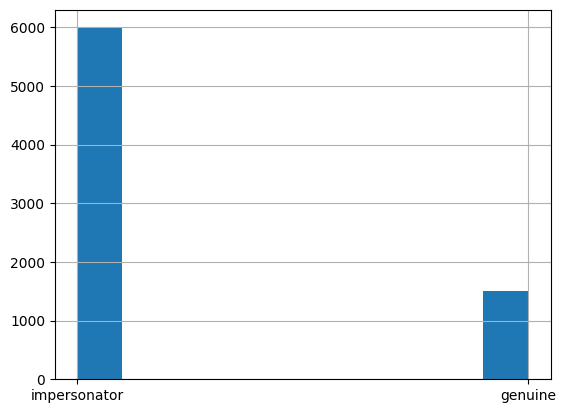

In [83]:
combined_testing['label'].hist()

In [16]:
import itertools

attack_types = ['gan', 'gaussian', 'vae', 'naive']
adversarial_techniques_permutations = []

# Generate all permutations of attack_types in different sizes
for size in range(1, len(attack_types) + 1):
    for permutation in itertools.permutations(attack_types, size):
        permutation = list(permutation)
        permutation.sort()
        if permutation not in adversarial_techniques_permutations:
            adversarial_techniques_permutations.append(permutation)
adversarial_techniques_permutations

[['gan'],
 ['gaussian'],
 ['vae'],
 ['naive'],
 ['gan', 'gaussian'],
 ['gan', 'vae'],
 ['gan', 'naive'],
 ['gaussian', 'vae'],
 ['gaussian', 'naive'],
 ['naive', 'vae'],
 ['gan', 'gaussian', 'vae'],
 ['gan', 'gaussian', 'naive'],
 ['gan', 'naive', 'vae'],
 ['gaussian', 'naive', 'vae'],
 ['gan', 'gaussian', 'naive', 'vae']]

In [31]:
results = pd.DataFrame(columns=['techniques', 'accuracy', 'balanced_accuracy', 'mcc'])

for attack_types in adversarial_techniques_permutations:
    variable_training_df = pd.DataFrame()
    training_string = ''
    print(attack_types)
    if 'naive' in attack_types:
        # 3000 rows was found to give good acc/data tradeoff
        variable_training_df = pd.concat([variable_training_df, naive_training[:3000]])
        training_string += 'naive_'
    
    if 'gaussian' in attack_types:
        # 1000 rows was found to give good acc/data tradeoff
        variable_training_df = pd.concat([variable_training_df, gaussian_copula_training[:1000]])
        training_string += 'gaussian_'

    if 'gan' in attack_types:
        # 4000 rows was found to give good acc/data tradeoff
        variable_training_df = pd.concat([variable_training_df, gan_training[:4000]])
        training_string += 'gan_'

    if 'vae' in attack_types:
        # 5000 rows was found to give good acc/data tradeoff
        variable_training_df = pd.concat([variable_training_df, vae_training[:5000]])
        training_string += 'vae_'
    
    variable_training_df.drop_duplicates(inplace=True)
    training_string = training_string[:-1]
    
    # print(len(variable_training_df))

    # print(training_string)
    
    predictor = TabularPredictor(label='label').fit(variable_training_df, num_gpus=1, presets='medium_quality', fit_weighted_ensemble=False)
    y_pred = predictor.predict(combined_testing)
    y_pred_proba = predictor.predict_proba(combined_testing)
    single_result = predictor.evaluate(combined_testing)
    
    new_results = {'techniques':training_string, 'accuracy':single_result['accuracy'], 'balanced_accuracy':single_result['balanced_accuracy'], 'mcc':single_result['mcc']}
    results.loc[len(results)] = (new_results)

No path specified. Models will be saved in: "AutogluonModels\ag-20250331_020909"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       52.09 GB / 63.72 GB (81.8%)
Disk Space Avail:   948.37 GB / 1906.98 GB (49.7%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 2 - Impersonation Detection\AutogluonModels\ag-20250331_020909"
Train Data Rows:    4000
Train Data Columns: 8
Label Column:       label
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['genuine', 'impersonator']
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may s

['gan']


	0.91	 = Validation score   (accuracy)
	3.5s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...


[1000]	valid_set's binary_error: 0.092


	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.


...

	0.95	 = Validation score   (accuracy)
	15.61s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9667	 = Validation score   (accuracy)
	3.0s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9489	 = Validation score   (accuracy)
	0.45s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9467	 = Validation score   (accuracy)
	0.44s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.8967	 = Validation score   (accuracy)

['gan', 'gaussian', 'naive', 'vae']
[1000]	valid_set's binary_error: 0.0692308
[2000]	valid_set's binary_error: 0.0492308
[3000]	valid_set's binary_error: 0.0453846


	0.9554	 = Validation score   (accuracy)
	14.16s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.


[1000]	valid_set's binary_error: 0.0223077


	0.9785	 = Validation score   (accuracy)
	5.81s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.96	 = Validation score   (accuracy)
	0.48s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9623	 = Validation score   (accuracy)
	0.47s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9269	 = Validation score   (accuracy)
	0.4s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: ExtraTreesEntr ...
	0.9269	 = Validation score   (accuracy)
	0.39s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: NeuralNetFastAI ...
	0.6169

In [35]:
predictor.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.978462,accuracy,0.017111,5.870503,0.000000,0.062049,2,True,13
1,LightGBM,0.978462,accuracy,0.017111,5.808455,0.017111,5.808455,1,True,4
2,XGBoost,0.976154,accuracy,0.016023,2.343557,0.016023,2.343557,1,True,10
3,LightGBMLarge,0.975385,accuracy,0.012804,16.481405,0.012804,16.481405,1,True,12
4,RandomForestEntr,0.962308,accuracy,0.043723,0.474780,0.043723,0.474780,1,True,6
5,RandomForestGini,0.960000,accuracy,0.043896,0.475875,0.043896,0.475875,1,True,5
6,LightGBMXT,0.955385,accuracy,0.018734,14.159725,0.018734,14.159725,1,True,3
7,ExtraTreesGini,0.926923,accuracy,0.043282,0.395691,0.043282,0.395691,1,True,7
8,ExtraTreesEntr,0.926923,accuracy,0.043573,0.392814,0.043573,0.392814,1,True,8
9,NeuralNetTorch,0.904615,accuracy,0.000000,108.199409,0.000000,108.199409,1,True,11


In [32]:
single_result

{'accuracy': 0.9476,
 'balanced_accuracy': np.float64(0.9385),
 'mcc': np.float64(0.844461543676741),
 'roc_auc': np.float64(0.9846601111111111),
 'f1': np.float64(0.966799020021965),
 'precision': np.float64(0.9802980983381874),
 'recall': np.float64(0.9536666666666667)}

In [33]:
results

,techniques,accuracy,balanced_accuracy,mcc
0,gan,0.773467,0.839417,0.552868
1,gaussian,0.470933,0.669333,0.304802
2,vae,0.880400,0.901250,0.704578
3,naive,0.713600,0.805000,0.488920
4,gaussian_gan,0.872000,0.903250,0.697441
5,gan_vae,0.903600,0.912500,0.745649
6,naive_gan,0.905733,0.922083,0.757085
7,gaussian_vae,0.938800,0.931750,0.821758
8,naive_gaussian,0.696267,0.795167,0.472409
9,naive_vae,0.942267,0.934917,0.830861


# Naive + Gaussian + VAE gave best accuracy on combined_testing

<Axes: xlabel='techniques', ylabel='value'>

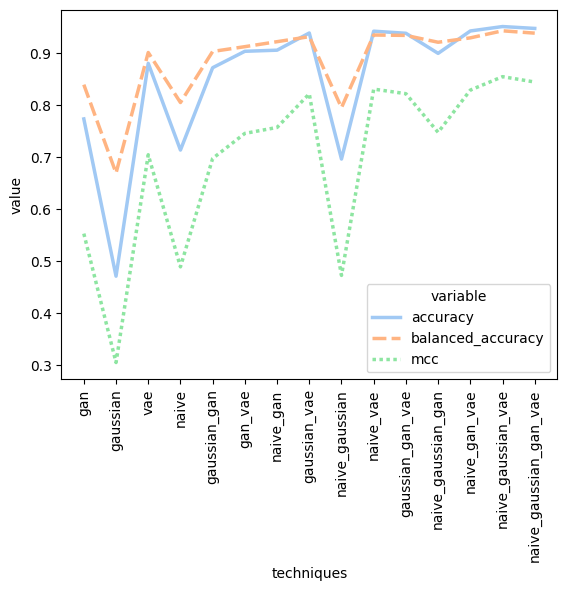

In [34]:
plt.xticks(rotation=90)
sns.lineplot(data=pd.melt(results, ['techniques']), x='techniques', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

# Training better quality model

In [109]:
results = pd.DataFrame(columns=['techniques', 'accuracy', 'balanced_accuracy', 'mcc'])


variable_training_df = pd.concat([naive_training[:3000], gaussian_copula_training[:1000], vae_training[:5000]])
variable_training_df.drop_duplicates(inplace=True)

variable_training_df.reset_index(inplace=True)

variable_training_df.drop(labels=['index', 'Unnamed: 0'], axis=1, inplace=True)
    
training_string = 'naive_gaussian_vae'
    
predictor = TabularPredictor(label='label', eval_metric='mcc').fit(variable_training_df, num_gpus=1, presets='medium_quality', fit_weighted_ensemble=False)
y_pred = predictor.predict(combined_testing)
y_pred_proba = predictor.predict_proba(combined_testing)
single_result = predictor.evaluate(combined_testing)

new_results = {'techniques':training_string, 'accuracy':single_result['accuracy'], 'balanced_accuracy':single_result['balanced_accuracy'], 'mcc':single_result['mcc']}
results.loc[len(results)] = (new_results)

No path specified. Models will be saved in: "AutogluonModels\ag-20250331_052240"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       47.60 GB / 63.72 GB (74.7%)
Disk Space Avail:   906.38 GB / 1906.98 GB (47.5%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 2 - Impersonation Detection\AutogluonModels\ag-20250331_052240"
Train Data Rows:    7779
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['impersonator', 'genuine']
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may s

[1000]	valid_set's binary_logloss: 0.239306	valid_set's mcc: 0.815406


	0.8418	 = Validation score   (mcc)
	10.22s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.


[1000]	valid_set's binary_logloss: 0.181021	valid_set's mcc: 0.881681


	0.887	 = Validation score   (mcc)
	8.78s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8397	 = Validation score   (mcc)
	0.44s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.8449	 = Validation score   (mcc)
	0.43s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.8023	 = Validation score   (mcc)
	0.36s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: ExtraTreesEntr ...
	0.805	 = Validation score   (mcc)
	0.4s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: NeuralNetFastAI ...
Metric mcc is not supported by t

[1000]	valid_set's binary_logloss: 0.241873	valid_set's mcc: 0.881681


	0.8817	 = Validation score   (mcc)
	25.06s	 = Training   runtime
	0.02s	 = Validation runtime
AutoGluon training complete, total runtime = 112.38s ... Best model: LightGBM | Estimated inference throughput: 43314.3 rows/s (778 batch size)
Enabling decision threshold calibration (calibrate_decision_threshold='auto', metric is valid, problem_type is 'binary')
Calibrating decision threshold to optimize metric mcc | Checking 51 thresholds...
Calibrating decision threshold via fine-grained search | Checking 38 thresholds...
	Base Threshold: 0.500	| val: 0.8870
	Best Threshold: 0.500	| val: 0.8870
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 2 - Impersonation Detection\AutogluonModels\ag-20250331_052240")


In [110]:
predictor.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBM,0.886985,mcc,0.017962,8.776866,0.017962,8.776866,1,True,4
1,LightGBMLarge,0.881681,mcc,0.022689,25.056709,0.022689,25.056709,1,True,12
2,XGBoost,0.870870,mcc,0.023914,4.763931,0.023914,4.763931,1,True,10
3,RandomForestEntr,0.844897,mcc,0.044559,0.434309,0.044559,0.434309,1,True,6
4,LightGBMXT,0.841791,mcc,0.009226,10.222780,0.009226,10.222780,1,True,3
5,RandomForestGini,0.839734,mcc,0.045917,0.442590,0.045917,0.442590,1,True,5
6,ExtraTreesEntr,0.805023,mcc,0.044012,0.395152,0.044012,0.395152,1,True,8
7,ExtraTreesGini,0.802333,mcc,0.044240,0.358242,0.044240,0.358242,1,True,7
8,NeuralNetTorch,0.757164,mcc,0.006133,57.229740,0.006133,57.229740,1,True,11
9,KNeighborsDist,0.516416,mcc,0.024934,0.005480,0.024934,0.005480,1,True,2


In [111]:
for model in ['LightGBM', 'LightGBMLarge', 'XGBoost']:
    print(model)
    y_pred = predictor.predict(combined_testing, model=model)
    y_pred_proba = predictor.predict_proba(combined_testing, model=model)
    single_result = predictor.evaluate(combined_testing, model=model)
    print(single_result)

LightGBM
{'mcc': np.float64(0.8403976872826412), 'accuracy': 0.9449333333333333, 'balanced_accuracy': np.float64(0.9420833333333334), 'roc_auc': np.float64(0.9869111111111112), 'f1': np.float64(0.9649256900212314), 'precision': np.float64(0.9837229437229438), 'recall': np.float64(0.9468333333333333)}
LightGBMLarge
{'mcc': np.float64(0.8544807271816404), 'accuracy': 0.9498666666666666, 'balanced_accuracy': np.float64(0.9486666666666667), 'roc_auc': np.float64(0.9885362222222223), 'f1': np.float64(0.9680923285811269), 'precision': np.float64(0.9861687413554634), 'recall': np.float64(0.9506666666666667)}
XGBoost
{'mcc': np.float64(0.8355368347894537), 'accuracy': 0.9430666666666667, 'balanced_accuracy': np.float64(0.9404166666666667), 'roc_auc': np.float64(0.9861287222222221), 'f1': np.float64(0.9637059073523162), 'precision': np.float64(0.983347788378144), 'recall': np.float64(0.9448333333333333)}


In [112]:
predictor.feature_importance(combined_testing)

Computing feature importance via permutation shuffling for 7 features using 5000 rows with 5 shuffle sets...
	1.24s	= Expected runtime (0.25s per shuffle set)
	0.86s	= Actual runtime (Completed 5 of 5 shuffle sets)


,importance,stddev,p_value,n,p99_high,p99_low
Feature 3,0.063133,0.008521,0.000039,5,0.080678,0.045587
Feature 4,0.057173,0.010685,0.000140,5,0.079175,0.035172
Feature 5,0.055986,0.005839,0.000014,5,0.068008,0.043964
Feature 2,0.042794,0.003975,0.000009,5,0.050978,0.034610
Feature 6,0.040212,0.006401,0.000075,5,0.053392,0.027033
Feature 0,0.024081,0.003769,0.000070,5,0.031841,0.016320
Feature 1,0.011826,0.003946,0.001290,5,0.019951,0.003701


In [113]:
results

,techniques,accuracy,balanced_accuracy,mcc
0,naive_gaussian_vae,0.944933,0.942083,0.840398


In [117]:
# will return the path to the cloned predictor, identical to save_path_clone_opt
path_clone_opt = predictor.clone_for_deployment(path='impersonation_detection', model='LightGBMLarge')

Cloned TabularPredictor located in 'c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 2 - Impersonation Detection\AutogluonModels\ag-20250331_052240' to 'impersonation_detection'.
	To load the cloned predictor: predictor_clone = TabularPredictor.load(path="impersonation_detection")
Clone: Keeping minimum set of models required to predict with model 'LightGBMLarge'...
Deleting model KNeighborsUnif. All files under c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 2 - Impersonation Detection\impersonation_detection\models\KNeighborsUnif will be removed.
Deleting model KNeighborsDist. All files under c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 2 - Impersonation Detection\impersonation_detection\models\KNeighborsDist will be removed.
Deleting model LightGBMXT. All files under c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 2 - Impersonation Detection\impersonation_detection\models\LightGBMXT will be removed.
Deleting model LightGBM. All files under c:\Users\zac\Documents\gi

In [118]:
predictor_clone_opt = TabularPredictor.load(path='impersonation_detection')

In [119]:
predictor_clone_opt.leaderboard(combined_testing)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMLarge,0.854481,0.881681,mcc,0.062967,0.022689,25.056709,0.062967,0.022689,25.056709,1,True,1


In [120]:
size_original = predictor.disk_usage()
size_opt = predictor_clone_opt.disk_usage()
print(f'Size Original:  {size_original} bytes')
print(f'Size Optimized: {size_opt} bytes')
print(f'Optimized predictor achieved a {round((1 - (size_opt/size_original)) * 100, 1)}% reduction in disk usage.')

Size Original:  256904042 bytes
Size Optimized: 10626959 bytes
Optimized predictor achieved a 95.9% reduction in disk usage.
